# **NEURAL CTR**

Neural Click-Through-Rate. In this task, given a data set of 39 features containing info about an ad's impression and response amomng users, we know have to predict binary labels indicating 1 (user clicked) or 0 (user skipped).

In [28]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss, average_precision_score, f1_score
from sklearn.calibration import calibration_curve

# Data Pre-processing

In [15]:
def preprocess_ctr_data(csv_path):
    print("Loading data...")
    
    col_names = ['label'] + [f'I{i}' for i in range(1, 14)] + [f'C{i}' for i in range(1, 27)]

    df = pd.read_csv(csv_path, names=col_names, header=None)

    df['label'] = pd.to_numeric(df['label'], errors='coerce')
    df = df.dropna(subset=['label'])
    
    numeric_cols = [f'I{i}' for i in range(1, 14)]
    categorical_cols = [f'C{i}' for i in range(1, 27)]

    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
    
    print("Processing Numeric Features")
    for col in numeric_cols:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
        val_df[col] = pd.to_numeric(val_df[col], errors='coerce')
        
        median_val = train_df[col].median()
        train_df[col] = train_df[col].fillna(median_val)
        val_df[col] = val_df[col].fillna(median_val)

        min_val = train_df[col].min()
        train_df[col] = np.log1p(train_df[col] - min_val if min_val < 0 else train_df[col])
        val_df[col] = np.log1p(val_df[col] - min_val if min_val < 0 else val_df[col])

    scaler = StandardScaler()
    train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
    val_df[numeric_cols] = scaler.transform(val_df[numeric_cols]) 

    print("Processing Categorical Features")

    train_df[categorical_cols] = train_df[categorical_cols].fillna('<UNK>')
    val_df[categorical_cols] = val_df[categorical_cols].fillna('<UNK>')
    
    train_df[categorical_cols] = train_df[categorical_cols].astype(str)
    val_df[categorical_cols] = val_df[categorical_cols].astype(str)

    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train_df[categorical_cols] = encoder.fit_transform(train_df[categorical_cols])
    val_df[categorical_cols] = encoder.transform(val_df[categorical_cols])

    train_df[categorical_cols] = train_df[categorical_cols] + 1
    val_df[categorical_cols] = val_df[categorical_cols] + 1

    cat_dims = [int(train_df[col].max() + 2) for col in categorical_cols]
    
    return train_df, val_df, numeric_cols, categorical_cols, cat_dims

# Vanilla Neural Network

In [16]:
class CTRDataset(Dataset):
    def __init__(self, df, numeric_cols, categorical_cols):
        self.numeric = torch.tensor(df[numeric_cols].values, dtype=torch.float32)
        self.categorical = torch.tensor(df[categorical_cols].values, dtype=torch.long)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.numeric[idx], self.categorical[idx], self.labels[idx]

class VanillaCTR(nn.Module):
    def __init__(self, num_numeric, cat_dims, embed_dim=16, hidden_dims=[128, 64]):
        super().__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=dim, embedding_dim=embed_dim)
            for dim in cat_dims
        ])
        
        total_input_dim = num_numeric + (len(cat_dims) * embed_dim)

        layers = []
        in_dim = total_input_dim
        for out_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.BatchNorm1d(out_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, 1))
        self.mlp = nn.Sequential(*layers)
        
    def forward(self, numeric_x, cat_x):
        cat_embeds = [emb(cat_x[:, i]) for i, emb in enumerate(self.embeddings)]

        cat_concat = torch.cat(cat_embeds, dim=1)

        x = torch.cat([numeric_x, cat_concat], dim=1) 
        
        logits = self.mlp(x).squeeze(1)

        return logits

# Execution and Evaluation

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, epochs=5, lr=0.001):
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    history = {
        'train_loss': [], 'val_loss': [], 'val_roc_auc': [], 
        'val_pr_auc': [], 'val_accuracy': [], 'val_f1': []
    }
    
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for num_x, cat_x, labels in train_loader:
            num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits = model(num_x, cat_x)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item() * len(labels)
            
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        
        model.eval()
        total_val_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for num_x, cat_x, labels in val_loader:
                num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
                logits = model(num_x, cat_x)
                loss = criterion(logits, labels)
                total_val_loss += loss.item() * len(labels)

                probs = torch.sigmoid(logits)
                all_preds.extend(probs.cpu().numpy())
                all_targets.extend(labels.cpu().numpy())
                
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        
        roc_auc = roc_auc_score(all_targets, all_preds)
        pr_auc = average_precision_score(all_targets, all_preds)
        val_log_loss = log_loss(all_targets, all_preds)

        binary_preds = (all_preds >= 0.5).astype(int)
        acc = accuracy_score(all_targets, binary_preds)
        f1 = f1_score(all_targets, binary_preds)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_roc_auc'].append(roc_auc)
        history['val_pr_auc'].append(pr_auc)
        history['val_accuracy'].append(acc)
        history['val_f1'].append(f1)
        
        print(f"Epoch {epoch+1:02d}/{epochs:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | F1: {f1:.4f}")
        
    return history, all_preds, all_targets

In [21]:
import zipfile
import os

zip_path = '/Users/bhuv2/Desktop/WEC Assignment/WEC_ass_new/mandatory-tasks/recommender-systems-cf-to-dlrm/datasets/dataset (tasks 2 and 3).zip'
extract_dir = './extracted_ctr_data/'

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Extracted files: {os.listdir(extract_dir)}")

csv_path = f"{extract_dir}/train.csv"
train_df, val_df, numeric_cols, categorical_cols, cat_dims = preprocess_ctr_data(csv_path)

train_dataset = CTRDataset(train_df, numeric_cols, categorical_cols)
val_dataset = CTRDataset(val_df, numeric_cols, categorical_cols)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False)

Loading data...
Processing Numeric Features
Processing Categorical Features


/var/folders/2h/r_qs_dk17jg54ncyclqnph8h0000gn/T/ipykernel_71588/988454813.py:6: DtypeWarning: Columns (0: label, 1: I1, 2: I2, 3: I3, 4: I4, 5: I5, 6: I6, 7: I7, 8: I8, 9: I9, 10: I10, 11: I11, 12: I12, 13: I13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, names=col_names, header=None)


**Initialising Vanilla NN**

In [23]:
num_numeric = len(numeric_cols)
vanilla_model = VanillaCTR(
    num_numeric=num_numeric, 
    cat_dims=cat_dims, 
    embed_dim=16, 
    hidden_dims=[128, 64]
)

**Training and evaluation**


In [24]:
history_vanilla, preds_vanilla, targets_vanilla = train_and_evaluate(
    model=vanilla_model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=5, 
    lr=0.001
)

Epoch 01/05 | Train Loss: 0.4419 | Val Loss: 0.3009 | ROC-AUC: 0.6038 | PR-AUC: 0.0442 | F1: 0.0000
Epoch 02/05 | Train Loss: 0.2388 | Val Loss: 0.1957 | ROC-AUC: 0.6329 | PR-AUC: 0.0520 | F1: 0.0000
Epoch 03/05 | Train Loss: 0.1732 | Val Loss: 0.1571 | ROC-AUC: 0.6687 | PR-AUC: 0.0626 | F1: 0.0000
Epoch 04/05 | Train Loss: 0.1479 | Val Loss: 0.1445 | ROC-AUC: 0.6803 | PR-AUC: 0.0659 | F1: 0.0000
Epoch 05/05 | Train Loss: 0.1355 | Val Loss: 0.1392 | ROC-AUC: 0.6814 | PR-AUC: 0.0762 | F1: 0.0000


**Generating the metric plots**

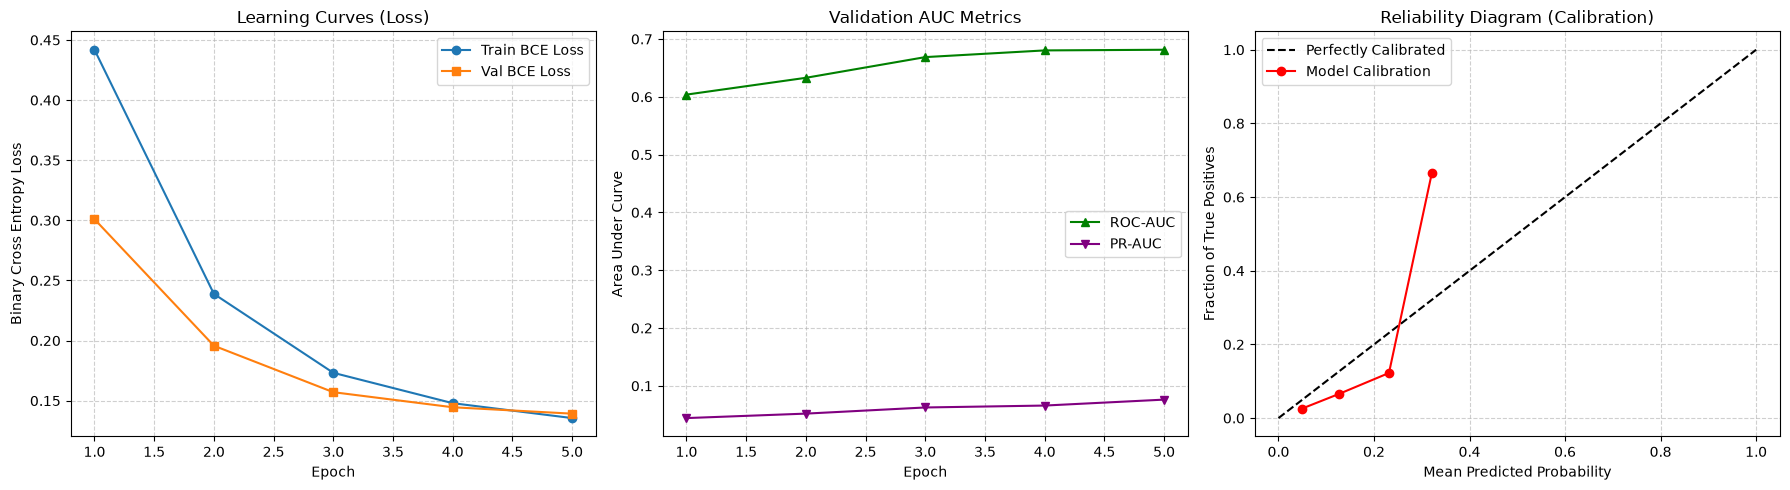

In [29]:
def plot_task2_metrics(history, all_preds, all_targets):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs_range = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs_range, history['train_loss'], label='Train BCE Loss', marker='o')
    axes[0].plot(epochs_range, history['val_loss'], label='Val BCE Loss', marker='s')
    axes[0].set_title('Learning Curves (Loss)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Binary Cross Entropy Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    axes[1].plot(epochs_range, history['val_roc_auc'], label='ROC-AUC', color='green', marker='^')
    axes[1].plot(epochs_range, history['val_pr_auc'], label='PR-AUC', color='purple', marker='v')
    axes[1].set_title('Validation AUC Metrics')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Area Under Curve')
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    prob_true, prob_pred = calibration_curve(all_targets, all_preds, n_bins=10, strategy='uniform')
    axes[2].plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated')
    axes[2].plot(prob_pred, prob_true, marker='o', color='red', label='Model Calibration')
    axes[2].set_title('Reliability Diagram (Calibration)')
    axes[2].set_xlabel('Mean Predicted Probability')
    axes[2].set_ylabel('Fraction of True Positives')
    axes[2].legend()
    axes[2].grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("task2_metrics.png", dpi=300)
    plt.show()

plot_task2_metrics(history_vanilla, preds_vanilla, targets_vanilla)